In [2]:
!unzip sample_mflix.zip

Archive:  sample_mflix.zip
   creating: sample_mflix/
  inflating: __MACOSX/._sample_mflix  
  inflating: sample_mflix/sessions.json  
  inflating: __MACOSX/sample_mflix/._sessions.json  
  inflating: sample_mflix/movies.json  
  inflating: __MACOSX/sample_mflix/._movies.json  
  inflating: sample_mflix/comments.json  
  inflating: __MACOSX/sample_mflix/._comments.json  
  inflating: sample_mflix/theaters.json  
  inflating: __MACOSX/sample_mflix/._theaters.json  
  inflating: sample_mflix/users.json  
  inflating: __MACOSX/sample_mflix/._users.json  


In [13]:
import os
from pymongo import MongoClient
import bson
from datetime import datetime
import pickle

In [4]:
client = MongoClient('mongodb://localhost:27017/')

In [5]:
client.server_info()

{'version': '8.0.4',
 'gitVersion': 'bc35ab4305d9920d9d0491c1c9ef9b72383d31f9',
 'modules': [],
 'allocator': 'tcmalloc-google',
 'javascriptEngine': 'mozjs',
 'sysInfo': 'deprecated',
 'versionArray': [8, 0, 4, 0],
 'openssl': {'running': 'OpenSSL 3.0.13 30 Jan 2024',
  'compiled': 'OpenSSL 3.0.13 30 Jan 2024'},
 'buildEnvironment': {'distmod': 'ubuntu2404',
  'distarch': 'x86_64',
  'cc': '/opt/mongodbtoolchain/v4/bin/gcc: gcc (GCC) 11.3.0',
  'ccflags': '-Werror -include mongo/platform/basic.h -ffp-contract=off -fasynchronous-unwind-tables -g2 -Wall -Wsign-compare -Wno-unknown-pragmas -Winvalid-pch -gdwarf-5 -fno-omit-frame-pointer -fno-strict-aliasing -O2 -march=sandybridge -mtune=generic -mprefer-vector-width=128 -Wno-unused-local-typedefs -Wno-unused-function -Wno-deprecated-declarations -Wno-unused-const-variable -Wno-unused-but-set-variable -Wno-missing-braces -Wno-psabi -fstack-protector-strong -gdwarf64 -Wa,--nocompress-debug-sections -fno-builtin-memcmp -Wimplicit-fallthroug

In [7]:
db = client.sample_mflix

In [8]:
json_dir = 'sample_mflix'
json_files = [f for f in os.listdir(json_dir) if f.endswith(".json")]
collections = [f.replace(".json", "") for f in json_files]
collections

['comments', 'theaters', 'sessions', 'movies', 'users']

In [9]:
for idx, json_file in enumerate(json_files):
    with open(os.path.join(json_dir, json_file), 'r') as f:
        for line in f:
            data = bson.json_util.loads(line.strip())
            db[collections[idx]].insert_one(data)
        print(f"Loaded {json_file} into the '{collections[idx]}' collection.")

Loaded comments.json into the 'comments' collection.
Loaded theaters.json into the 'theaters' collection.
Loaded sessions.json into the 'sessions' collection.
Loaded movies.json into the 'movies' collection.
Loaded users.json into the 'users' collection.


In [10]:
db.list_collection_names()

['theaters', 'users', 'sessions', 'movies', 'comments']

In [20]:
#q1
q1 = db.movies.find_one({})
with open('answers/q1.pkl', 'wb') as f:
   pickle.dump(q1, f)
q1

{'_id': ObjectId('573a1390f29313caabcd4135'),
 'plot': 'Three men hammer on an anvil and pass a bottle of beer around.',
 'genres': ['Short'],
 'runtime': 1,
 'cast': ['Charles Kayser', 'John Ott'],
 'num_mflix_comments': 1,
 'title': 'Blacksmith Scene',
 'fullplot': 'A stationary camera looks at a large anvil with a blacksmith behind it and one on either side. The smith in the middle draws a heated metal rod from the fire, places it on the anvil, and all three begin a rhythmic hammering. After several blows, the metal goes back in the fire. One smith pulls out a bottle of beer, and they each take a swig. Then, out comes the glowing metal and the hammering resumes.',
 'countries': ['USA'],
 'released': datetime.datetime(1893, 5, 9, 0, 0),
 'directors': ['William K.L. Dickson'],
 'rated': 'UNRATED',
 'awards': {'wins': 1, 'nominations': 0, 'text': '1 win.'},
 'lastupdated': '2015-08-26 00:03:50.133000000',
 'year': 1893,
 'imdb': {'rating': 6.2, 'votes': 1189, 'id': 5},
 'type': 'movie'

In [21]:
#q2
q2_cursor = db.movies.find({"directors": "Christopher Nolan"})
q2 = list(q2_cursor)
with open('answers/q2.pkl', 'wb') as f:
    pickle.dump(q2, f)
q2

[{'_id': ObjectId('573a139df29313caabcf8dd4'),
  'fullplot': "An older man listens to Bill's story about being a callow writer who likes to follow strangers around London, observing them. One day, a glib and self-confident man whom Bill has been following confronts him. He's Cobb, a burglar who takes Bill under his wing and shows him how to break and enter. They burgle a woman's flat; Bill gets intrigued with her (photographs are everywhere in her flat). He follows her and chats her up at a bar owned by her ex-boyfriend, a nasty piece of work who killed someone in her living room with a hammer. Soon Bill is volunteering to do her a favor, which involves a break-in. What does the older man know that Bill doesn't?",
  'imdb': {'rating': 7.6, 'votes': 59767, 'id': 154506},
  'year': 1998,
  'plot': 'A young writer who follows strangers for material meets a thief who takes him under his wing.',
  'genres': ['Mystery', 'Thriller'],
  'rated': 'R',
  'metacritic': 60,
  'title': 'Following',

In [22]:
#q3
q3_cursor = db.users.find({}).limit(5)
q3 = list(q3_cursor)
with open('answers/q3.pkl', 'wb') as f:
    pickle.dump(q3, f)
q3

[{'_id': ObjectId('59b99db4cfa9a34dcd7885b6'),
  'name': 'Ned Stark',
  'email': 'sean_bean@gameofthron.es',
  'password': '$2b$12$UREFwsRUoyF0CRqGNK0LzO0HM/jLhgUCNNIJ9RJAqMUQ74crlJ1Vu'},
 {'_id': ObjectId('59b99db4cfa9a34dcd7885b7'),
  'name': 'Robert Baratheon',
  'email': 'mark_addy@gameofthron.es',
  'password': '$2b$12$yGqxLG9LZpXA2xVDhuPnSOZd.VURVkz7wgOLY3pnO0s7u2S1ZO32y'},
 {'_id': ObjectId('59b99db5cfa9a34dcd7885b8'),
  'name': 'Jaime Lannister',
  'email': 'nikolaj_coster-waldau@gameofthron.es',
  'password': '$2b$12$6vz7wiwO.EI5Rilvq1zUc./9480gb1uPtXcahDxIadgyC3PS8XCUK'},
 {'_id': ObjectId('59b99db5cfa9a34dcd7885b9'),
  'name': 'Catelyn Stark',
  'email': 'michelle_fairley@gameofthron.es',
  'password': '$2b$12$fiaTH5Sh1zKNFX2i/FTEreWGjxoJxvmV7XL.qlfqCr8CwOxK.mZWS'},
 {'_id': ObjectId('59b99db6cfa9a34dcd7885ba'),
  'name': 'Cersei Lannister',
  'email': 'lena_headey@gameofthron.es',
  'password': '$2b$12$FExjgr7CLhNCa.oUsB9seub8mqcHzkJCFZ8heMc8CeIKOZfeTKP8m'}]

In [32]:
#q4
q4 = db.movies.find_one({"imdb.rating": {"$gt": 9}})
with open('answers/q4.pkl', 'wb') as f:
    pickle.dump(q4, f)
q4

{'_id': ObjectId('573a1396f29313caabce4a9a'),
 'fullplot': 'When the aging head of a famous crime family decides to transfer his position to one of his subalterns, a series of unfortunate events start happening to the family, and a war begins between all the well-known families leading to insolence, deportation, murder and revenge, and ends with the favorable successor being finally chosen.',
 'imdb': {'rating': 9.2, 'votes': 1038358, 'id': 68646},
 'year': 1972,
 'plot': 'The aging patriarch of an organized crime dynasty transfers control of his clandestine empire to his reluctant son.',
 'genres': ['Crime', 'Drama'],
 'rated': 'R',
 'metacritic': 100,
 'title': 'The Godfather',
 'lastupdated': '2015-09-02 00:08:23.680000000',
 'languages': ['English', 'Italian', 'Latin'],
 'writers': ['Mario Puzo (screenplay)',
  'Francis Ford Coppola (screenplay)',
  'Mario Puzo (novel)'],
 'type': 'movie',
 'tomatoes': {'website': 'http://www.thegodfather.com',
  'viewer': {'rating': 4.4, 'numRevie

In [35]:
#q5
q5 = db.movies.count_documents({})
with open('answers/q5.pkl', 'wb') as f:
    pickle.dump(q5, f)
q5

23539

In [38]:
#q6
q6 = db.movies.count_documents({"year": {"$gt": 2000}})
with open('answers/q6.pkl', 'wb') as f:
    pickle.dump(q6, f)
q6

13103

In [39]:
#q7
q7 = db.movies.count_documents({"genres": "Comedy"})
with open('answers/q7.pkl', 'wb') as f:
    pickle.dump(q7, f)
q7

7024

In [41]:
#q8
q8 = db.comments.count_documents({"name": "Taylor Hill"})
with open('answers/q8.pkl', 'wb') as f:
    pickle.dump(q8, f)
q8

279

In [42]:
#q9
q9 = db.movies.count_documents({"runtime": {"$gt": 120}})
with open('answers/q9.pkl', 'wb') as f:
    pickle.dump(q9, f)
q9

3722

In [44]:
#q10
q10_cursor = db.movies.find(
    {"year": 2015},
    {"_id": 0, "title": 1}
).sort("title", 1)
q10 = list(q10_cursor)
with open('answers/q10.pkl', 'wb') as f:
    pickle.dump(q10, f)
q10

[{'title': '(T)ERROR'},
 {'title': '11 Minutes'},
 {'title': '13 Minutes'},
 {'title': '3 1/2 Minutes, Ten Bullets'},
 {'title': '45 Years'},
 {'title': '6 Years'},
 {'title': '600 Millas'},
 {'title': '7 Chinese Brothers'},
 {'title': 'A Bigger Splash'},
 {'title': 'A Brave Heart: The Lizzie Velasquez Story'},
 {'title': 'A Country Called Home'},
 {'title': 'A Horse for Summer'},
 {'title': 'A Perfect Day'},
 {'title': 'A Sinner in Mecca'},
 {'title': 'A Sunday Kind of Love'},
 {'title': 'A Tale of Love and Darkness'},
 {'title': 'A War'},
 {'title': 'A cambio de nada'},
 {'title': 'Above and Below'},
 {'title': 'Ad Inexplorata'},
 {'title': 'Adam Curtis: Bitter Lake'},
 {'title': 'Adama'},
 {'title': 'Admiral'},
 {'title': 'Advantageous'},
 {'title': 'Aferim!'},
 {'title': 'AfterDeath'},
 {'title': 'Alias Marèa'},
 {'title': 'Alice in Earnestland'},
 {'title': 'All Eyes and Ears'},
 {'title': 'Aloha'},
 {'title': 'American Hostage'},
 {'title': 'Amy'},
 {'title': 'An'},
 {'title': 'A

In [80]:
#q11
q11_cursor = db.comments.find().sort("date", -1).limit(5)
q11 = list(q11_cursor)
with open('answers/q11.pkl', 'wb') as f:
    pickle.dump(q11, f)
q11

[{'_id': ObjectId('5b7327c34a68c3f7a7bcb1d3'),
  'name': 'sxkybvzb6',
  'email': 'vtz4prjvb@g622o.1yk',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'fazzlebizzle',
  'date': datetime.datetime(2018, 8, 14, 15, 5, 3, 142000)},
 {'_id': ObjectId('5b7327724a68c3f7a7bcb1ae'),
  'name': 'jjjdmntww',
  'email': 'h90xxa9b0@gn3q7.7th',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'feefee',
  'date': datetime.datetime(2018, 8, 14, 15, 3, 14, 306000)},
 {'_id': ObjectId('5b7326fd4a68c3f7a7bcb188'),
  'name': 'yznjm1yul',
  'email': 'rio72go4u@wztfh.ep0',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'feefee',
  'date': datetime.datetime(2018, 8, 14, 15, 1, 16, 716000)},
 {'_id': ObjectId('5b7326bd4a68c3f7a7bcb15f'),
  'name': 'sg1u6swo4',
  'email': 'gs4jr54ar@6gvpw.ok0',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'fazzlebizzle',
  'date': datetime.datetime(2018, 8, 14, 15, 0, 25, 211000)},
 {'_id': ObjectId('5b7325024a68c3f7a7

In [48]:
#q12
q12 = db.movies.count_documents({"genres": {"$all": ["Action", "Adventure"]}})
with open('answers/q12.pkl', 'wb') as f:
    pickle.dump(q12, f)
q12

779

In [49]:
#q13
q13_cursor = db.movies.find(
    {"imdb.rating": {"$gte": 9, "$lte": 10}},
    {"_id": 0, "title": 1, "imdb.rating": 1, "genres": 1, "year": 1}
)
q13 = list(q13_cursor)
with open('answers/q13.pkl', 'wb') as f:
    pickle.dump(q13, f)
q13

[{'imdb': {'rating': 9.2},
  'year': 1972,
  'genres': ['Crime', 'Drama'],
  'title': 'The Godfather'},
 {'imdb': {'rating': 9.1},
  'year': 1974,
  'genres': ['Crime', 'Drama'],
  'title': 'The Godfather: Part II'},
 {'genres': ['Drama', 'History'],
  'title': 'I, Claudius',
  'year': 1976,
  'imdb': {'rating': 9}},
 {'genres': ['Documentary', 'History'],
  'title': 'Hollywood',
  'year': 1980,
  'imdb': {'rating': 9.1}},
 {'genres': ['Documentary'],
  'title': 'Cosmos',
  'year': 1980,
  'imdb': {'rating': 9.3}},
 {'genres': ['Comedy', 'Drama'],
  'title': 'The Marathon Family',
  'year': 1982,
  'imdb': {'rating': 9}},
 {'genres': ['Drama'],
  'title': 'The Decalogue',
  'year': 1989,
  'imdb': {'rating': 9.2}},
 {'genres': ['Comedy', 'Drama', 'Sci-Fi'],
  'title': 'Heart of a Dog',
  'year': 1988,
  'imdb': {'rating': 9}},
 {'genres': ['Documentary', 'History', 'War'],
  'title': 'The Civil War',
  'year': 1990,
  'imdb': {'rating': 9.4}},
 {'genres': ['Documentary', 'History', 'Sp

In [50]:
#q14
q14 = db.movies.count_documents({"directors": {"$exists": True, "$size": 3}})
with open('answers/q14.pkl', 'wb') as f:
    pickle.dump(q14, f)
q14

181

In [51]:
#q15
q15 = db.movies.count_documents({
    "directors": {"$exists": True},
    "$expr": {"$gte": [{"$size": "$directors"}, 3]}
})
with open('answers/q15.pkl', 'wb') as f:
    pickle.dump(q15, f)
q15

296

In [52]:
#q16
movies_2010 = list(db.movies.find({"year": 2010}, {"_id": 1}))
movie_ids_2010 = [m["_id"] for m in movies_2010]
q16 = db.comments.count_documents({"movie_id": {"$in": movie_ids_2010}})
with open('answers/q16.pkl', 'wb') as f:
    pickle.dump(q16, f)
q16

510

In [54]:
#q17
action_movie_ids = list(db.movies.find({"genres": "Action"}, {"_id": 1}))
action_ids = [m["_id"] for m in action_movie_ids]
users_action = db.comments.distinct("name", {"movie_id": {"$in": action_ids}})
q17 = sorted(users_action)
with open('answers/q17.pkl', 'wb') as f:
    pickle.dump(q17, f)
q17

['Alliser Thorne',
 'Amy Phillips',
 'Amy Ramirez',
 'Andrea Le',
 'Anthony Cline',
 'Anthony Hurst',
 'Anthony Smith',
 'Anthony Thompson',
 'April Cole',
 'Arya Stark',
 'Ashlee Hart',
 'Barbara Gonzalez',
 'Barristan Selmy',
 'Beric Dondarrion',
 'Blake Fitzgerald',
 'Blake Sellers',
 'Bowen Marsh',
 'Bradley Brooks',
 'Bran Stark',
 'Brandon Hardy',
 'Brenda Martin',
 'Brienne of Tarth',
 'Bronn',
 'Cameron Duran',
 'Catelyn Stark',
 'Catherine Romero',
 'Cersei Lannister',
 'Christian Williams',
 'Christopher Robinson',
 'Connie Barton',
 'Connie Johnson',
 'Daario Naharis',
 'Daenerys Targaryen',
 'Daniel Simmons',
 'Davos Seaworth',
 'Deborah Kennedy',
 'Denise Bryant',
 'Denise Davidson',
 'Desiree Pierce',
 'Donna Russell',
 'Donna Smith',
 'Doreah',
 'Eddison Tollett',
 'Edward Barrett',
 'Elizabeth Wiggins',
 'Ellaria Sand',
 'Emily Ellis',
 'Eric Navarro',
 'Garrett Obrien',
 'Gendry',
 'Gilly',
 'Grand Maester Pycelle',
 'Greg Powell',
 'Gregor Clegane',
 'Grenn',
 'Grey W

In [56]:
#q18
start_date = datetime(2018, 8, 13)
q18_cursor = db.comments.find({"date": {"$gte": start_date}})
q18 = list(q18_cursor)
with open('answers/q18.pkl', 'wb') as f:
    pickle.dump(q18, f)
q18

[{'_id': ObjectId('5b71c2884a68c30929b2a9f1'),
  'name': 'bbw6dadfe',
  'email': '7o9jvpos7@zmu2t.koi',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'fazzlebizzle',
  'date': datetime.datetime(2018, 8, 13, 13, 40, 29, 394000)},
 {'_id': ObjectId('5b71c8444a68c315a80b046a'),
  'name': 'ztcviee3w',
  'email': 'k5s0qzhgq@bura0.b9j',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'fazzlebizzle',
  'date': datetime.datetime(2018, 8, 13, 14, 4, 57, 526000)},
 {'_id': ObjectId('5b721c0020a32767b53b0ef0'),
  'name': 'y5uve0uql',
  'email': '7ba24unv0@f93ng.s96',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'fazzlebizzle',
  'date': datetime.datetime(2018, 8, 13, 20, 2, 12, 67000)},
 {'_id': ObjectId('5b721c8820a32768c1dd5b97'),
  'name': 'z49ahxnxe',
  'email': '7ypfpywp6@z618q.oc0',
  'movie_id': ObjectId('573a13eff29313caabdd82f3'),
  'text': 'fazzlebizzle',
  'date': datetime.datetime(2018, 8, 13, 20, 4, 28, 72000)},
 {'_id': ObjectId('5b721d

In [57]:
#q19
spielberg_movie_ids = list(db.movies.find({"directors": "Steven Spielberg"}, {"_id": 1}))
sb_ids = [m["_id"] for m in spielberg_movie_ids]
q19 = db.comments.count_documents({"movie_id": {"$in": sb_ids}})
with open('answers/q19.pkl', 'wb') as f:
    pickle.dump(q19, f)
q19

1269

In [59]:
#q20
q20_cursor = db.movies.find(
    {"imdb.rating": {"$gt": 9.0}},
    {"_id": 0, "title": 1, "released": 1, "imdb.rating": 1}
).sort("released", -1).limit(10)
q20 = list(q20_cursor)
with open('answers/q20.pkl', 'wb') as f:
    pickle.dump(q20, f)
q20

[{'title': 'A Brave Heart: The Lizzie Velasquez Story',
  'released': datetime.datetime(2015, 9, 25, 0, 0),
  'imdb': {'rating': 9.4}},
 {'title': 'The Real Miyagi',
  'released': datetime.datetime(2015, 2, 20, 0, 0),
  'imdb': {'rating': 9.3}},
 {'title': 'Over the Garden Wall',
  'released': datetime.datetime(2014, 11, 3, 0, 0),
  'imdb': {'rating': 9.2}},
 {'title': 'Frozen Planet',
  'released': datetime.datetime(2012, 3, 18, 0, 0),
  'imdb': {'rating': 9.2}},
 {'title': 'Human Planet',
  'released': datetime.datetime(2011, 1, 13, 0, 0),
  'imdb': {'rating': 9.2}},
 {'title': 'Life',
  'released': datetime.datetime(2009, 10, 12, 0, 0),
  'imdb': {'rating': 9.2}},
 {'title': 'Planet Earth',
  'released': datetime.datetime(2007, 3, 25, 0, 0),
  'imdb': {'rating': 9.5}},
 {'title': 'The Blue Planet',
  'released': datetime.datetime(2002, 1, 27, 0, 0),
  'imdb': {'rating': 9.2}},
 {'title': 'Band of Brothers',
  'released': datetime.datetime(2001, 9, 9, 0, 0),
  'imdb': {'rating': 9.6}

In [62]:
#q21
commented_movie_ids = db.comments.distinct("movie_id")
q21 = db.movies.count_documents({"_id": {"$nin": commented_movie_ids}})
with open('answers/q21.pkl', 'wb') as f:
    pickle.dump(q21, f)
q21

16090

In [63]:
#q22
q22 = db.movies.count_documents({"title": {"$regex": r"^The"}})
with open('answers/q22.pkl', 'wb') as f:
    pickle.dump(q22, f)
q22

4477

In [68]:
#q23
q23_cursor = [
    {"$match": {"genres": "Action"}},
    {"$group": {"_id": None, "avg_rating": {"$avg": "$imdb.rating"}}}
]
result = list(db.movies.aggregate(q23_cursor))
avg_action_rating = round(result[0]["avg_rating"], 2)
q23 = {"average_rating": avg_action_rating}
with open('answers/q23.pkl', 'wb') as f:
    pickle.dump(q23, f)
q23

{'average_rating': 6.38}

In [69]:
#q24
q24_cursor = [
    {"$group": {"_id": "$name", "total_comments": {"$sum": 1}}},
    {"$sort": {"total_comments": -1, "_id": 1}},
    {"$limit": 5}
]
q24 = list(db.comments.aggregate(q24_cursor))
with open('answers/q24.pkl', 'wb') as f:
    pickle.dump(q24, f)
q24

[{'_id': 'Mace Tyrell', 'total_comments': 331},
 {'_id': 'Missandei', 'total_comments': 327},
 {'_id': 'The High Sparrow', 'total_comments': 315},
 {'_id': 'Sansa Stark', 'total_comments': 308},
 {'_id': 'Rodrik Cassel', 'total_comments': 305}]

In [70]:
#q25
q25_cursor = [
    {"$group": {"_id": "$movie_id", "total_comments": {"$sum": 1}}},
    {"$lookup": {
        "from": "movies",
        "localField": "_id",
        "foreignField": "_id",
        "as": "movie_docs"
    }},
    {"$unwind": "$movie_docs"},
    {"$sort": {"total_comments": -1, "movie_docs.title": 1}},
    {"$limit": 5},
    {"$project": {
        "_id": 1,
        "total_comments": 1
    }}
]
q25 = list(db.comments.aggregate(q25_cursor))
with open('answers/q25.pkl', 'wb') as f:
    pickle.dump(q25, f)
q25

[{'_id': ObjectId('573a13bff29313caabd5e91e'), 'total_comments': 161},
 {'_id': ObjectId('573a13abf29313caabd25582'), 'total_comments': 158},
 {'_id': ObjectId('573a13a5f29313caabd159a9'), 'total_comments': 158},
 {'_id': ObjectId('573a13a3f29313caabd0d1e3'), 'total_comments': 158},
 {'_id': ObjectId('573a13b3f29313caabd3b647'), 'total_comments': 158}]

In [72]:
#q26
q26_cursor = [
    {"$match": {"genres": "Sci-Fi"}},
    {"$group": {"_id": None, "avg_runtime": {"$avg": "$runtime"}}}
]
result = list(db.movies.aggregate(q26_cursor))
avg_runtime = round(result[0]["avg_runtime"], 2)
q26 = {"average_runtime": avg_runtime}
with open('answers/q26.pkl', 'wb') as f:
    pickle.dump(q26, f)
q26

{'average_runtime': 103.05}

In [73]:
#q27
q27_cursor = [
    {"$unwind": "$directors"},
    {"$group": {"_id": "$directors", "count": {"$sum": 1}}},
    {"$sort": {"count": -1, "_id": 1}},
    {"$limit": 3}
]
q27 = list(db.movies.aggregate(q27_cursor))
with open('answers/q27.pkl', 'wb') as f:
    pickle.dump(q27, f)
q27

[{'_id': 'Woody Allen', 'count': 40},
 {'_id': 'John Ford', 'count': 35},
 {'_id': 'John Huston', 'count': 34}]

In [74]:
#q28
q28_cursor = [
    {"$group": {"_id": "$email", "comment_count": {"$sum": 1}}},
    {"$sort": {"comment_count": -1}},
    {"$limit": 5}
]
result = list(db.comments.aggregate(q28_cursor))
q28 = []
for doc in result:
    q28.append({
        "email": doc["_id"],
        "comment_count": doc["comment_count"]
    })
with open('answers/q28.pkl', 'wb') as f:
    pickle.dump(q28, f)
q28

[{'email': 'roger_ashton-griffiths@gameofthron.es', 'comment_count': 331},
 {'email': 'nathalie_emmanuel@gameofthron.es', 'comment_count': 327},
 {'email': 'jonathan_pryce@gameofthron.es', 'comment_count': 315},
 {'email': 'sophie_turner@gameofthron.es', 'comment_count': 308},
 {'email': 'ron_donachie@gameofthron.es', 'comment_count': 305}]

In [75]:
#q29
q29_cursor = [
    {"$unwind": "$genres"},
    {"$group": {"_id": "$genres", "average_rating": {"$avg": "$imdb.rating"}}},
    {"$sort": {"average_rating": -1}},
    {"$limit": 5}
]
result = list(db.movies.aggregate(q29_cursor))
for doc in result:
    doc["average_rating"] = round(doc["average_rating"], 2)
q29 = result
with open('answers/q29.pkl', 'wb') as f:
    pickle.dump(q29, f)
q29

[{'_id': 'Film-Noir', 'average_rating': 7.5},
 {'_id': 'Documentary', 'average_rating': 7.37},
 {'_id': 'Short', 'average_rating': 7.36},
 {'_id': 'News', 'average_rating': 7.25},
 {'_id': 'History', 'average_rating': 7.2}]

In [76]:
#q30
q30_cursor = [
    {"$lookup": {
        "from": "movies",
        "localField": "movie_id",
        "foreignField": "_id",
        "as": "movie_docs"
    }},
    {"$unwind": "$movie_docs"},
    {"$unwind": "$movie_docs.genres"},
    {"$group": {
        "_id": "$name",
        "genres_commented": {"$addToSet": "$movie_docs.genres"}
    }},
    {"$match": {
        "genres_commented": {"$all": ["Action", "Drama"]}
    }},
    {"$sort": {"_id": 1}},
    {"$project": {"_id": 1}}
]
q30 = list(db.comments.aggregate(q30_cursor))
with open('answers/q30.pkl', 'wb') as f:
    pickle.dump(q30, f)
q30

[{'_id': 'Alliser Thorne'},
 {'_id': 'Amy Phillips'},
 {'_id': 'Amy Ramirez'},
 {'_id': 'Andrea Le'},
 {'_id': 'Anthony Cline'},
 {'_id': 'Anthony Hurst'},
 {'_id': 'Anthony Smith'},
 {'_id': 'Anthony Thompson'},
 {'_id': 'April Cole'},
 {'_id': 'Arya Stark'},
 {'_id': 'Ashlee Hart'},
 {'_id': 'Barbara Gonzalez'},
 {'_id': 'Barristan Selmy'},
 {'_id': 'Beric Dondarrion'},
 {'_id': 'Blake Fitzgerald'},
 {'_id': 'Blake Sellers'},
 {'_id': 'Bowen Marsh'},
 {'_id': 'Bradley Brooks'},
 {'_id': 'Bran Stark'},
 {'_id': 'Brandon Hardy'},
 {'_id': 'Brenda Martin'},
 {'_id': 'Brienne of Tarth'},
 {'_id': 'Bronn'},
 {'_id': 'Cameron Duran'},
 {'_id': 'Catelyn Stark'},
 {'_id': 'Catherine Romero'},
 {'_id': 'Cersei Lannister'},
 {'_id': 'Christian Williams'},
 {'_id': 'Christopher Robinson'},
 {'_id': 'Connie Barton'},
 {'_id': 'Connie Johnson'},
 {'_id': 'Daario Naharis'},
 {'_id': 'Daenerys Targaryen'},
 {'_id': 'Daniel Simmons'},
 {'_id': 'Davos Seaworth'},
 {'_id': 'Deborah Kennedy'},
 {'_id':

In [78]:
#q31
q31_cursor = [
    {"$group": {
        "_id": "$name",
        "unique_movies": {"$addToSet": "$movie_id"}
    }},
    {"$project": {
        "unique_movies": {"$size": "$unique_movies"}
    }},
    {"$sort": {"unique_movies": -1}},
    {"$limit": 1}
]
q31 = list(db.comments.aggregate(q31_cursor))
with open('answers/q31.pkl', 'wb') as f:
    pickle.dump(q31, f)
q31

[{'_id': 'Mace Tyrell', 'unique_movies': 270}]

In [86]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
def plot_theaters(theaters, map_type, filename):
    assert map_type in ['wi', 'madison']
    assert filename in ['q32', 'q33', 'q34']
    gdf = gpd.GeoDataFrame(theaters, geometry=gpd.points_from_xy(
        [theater['location']['geo']['coordinates'][0] for theater in theaters],
        [theater['location']['geo']['coordinates'][1] for theater in theaters]
    ))
    world = gpd.read_file("wi_limits.geojson")
    if map_type == 'madison':
        world = gpd.read_file("madison_limits.geojson")
    gdf = gdf.set_crs(world.crs)
    ax = world.plot(figsize=(10, 6), color='lightgray', edgecolor='black')
    gdf.plot(ax=ax, marker='o', color='red', markersize=5)
    plt.title("Theater Locations")
    plt.grid(True)
    plt.savefig(f'{filename}.png')
    plt.show()

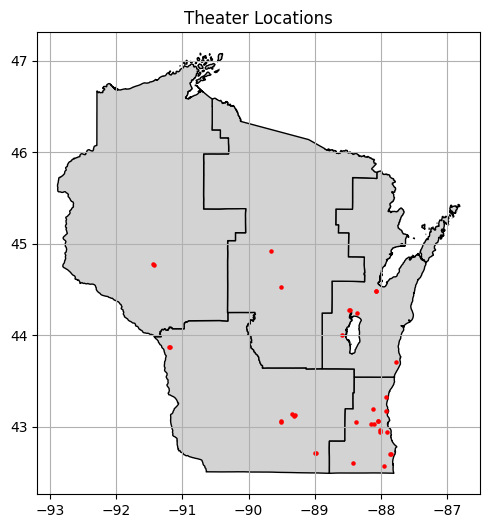

In [87]:
#q32
q32 = list(db.theaters.find({"location.address.state": "WI"}))
plot_theaters(q32, 'wi', 'q32')

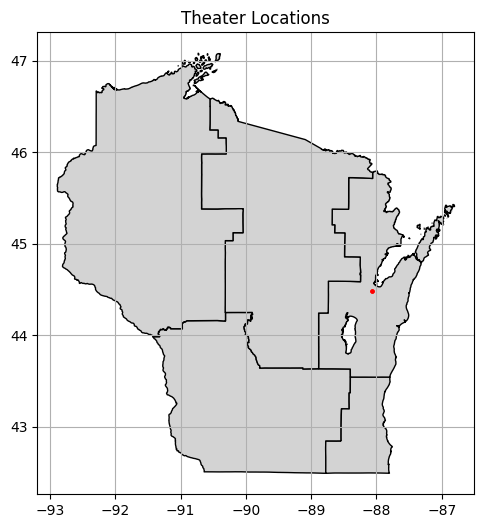

In [89]:
#q33
db.theaters.create_index([("location.geo", "2dsphere")])
park_coords = [-87.22109, 45.15602]
q33_cursor = db.theaters.find({
    "location.geo": {
        "$near": {
            "$geometry": {
                "type": "Point",
                "coordinates": park_coords
            }
        }
    }
}).limit(2)
q33_docs = list(q33_cursor)
plot_theaters(q33_docs, 'wi', 'q33')

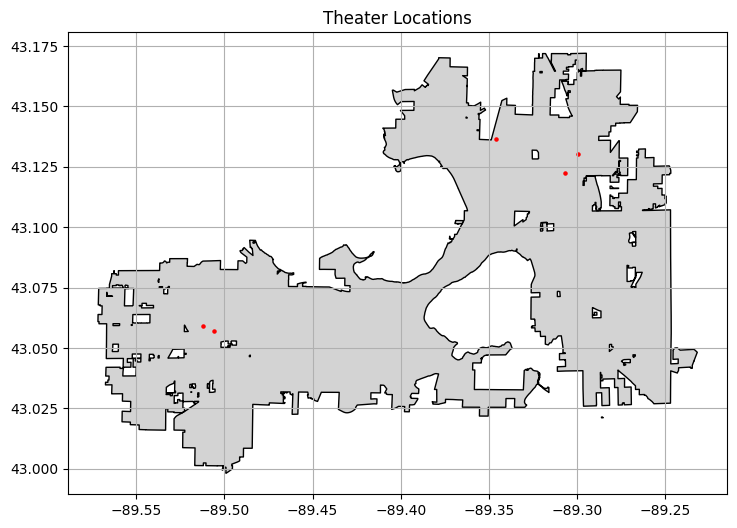

In [90]:
#q34
uw_coords = [-89.40816, 43.07540]
max_dist_meters = 16093.4
q34_cursor = db.theaters.find({
    "location.geo": {
        "$near": {
            "$geometry": {
                "type": "Point",
                "coordinates": uw_coords
            },
            "$maxDistance": max_dist_meters
        }
    }
})
q34_docs = list(q34_cursor)
plot_theaters(q34_docs, 'madison', 'q34')

In [91]:
!pytest --no-header -vv autograder.py

============================= test session starts ==============================
collected 39 items                                                             

PASSED                                   [  2%]
autograder.py::test_imports PASSED                                       [  5%]
autograder.py::test_mongodb_connection PASSED                            [  7%]
autograder.py::test_load_files_to_mongo PASSED                           [ 10%]
PASSED                             [ 12%]
autograder.py::test_numeric_match[5] PASSED (0.1/0.1)                    [ 15%]
autograder.py::test_numeric_match[6] PASSED (0.1/0.1)                    [ 17%]
autograder.py::test_numeric_match[7] PASSED (0.1/0.1)                    [ 20%]
autograder.py::test_numeric_match[8] PASSED (0.1/0.1)                    [ 23%]
autograder.py::test_numeric_match[9] PASSED (0.1/0.1)                    [ 25%]
autograder.py::test_numeric_match[12] PASSED (0.1/0.1)                   [ 28%]
autograder.py::test_numeric_